## 0. Preparation: Importing & Path Setting

In [1]:
#Imports
import pandas as pd # for data loading, cleaning, and time-series handling
import numpy as np   # for numerical operations
import matplotlib.pyplot as plt #for plotting the load curves

from statsmodels.tsa.statespace.sarimax import SARIMAX  # for ARIMA/SARIMA with exogenous regressors

from sklearn.preprocessing import MinMaxScaler  # for feature scaling in the LSTM model
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error  # to evaluate forecast accuracy

from tensorflow.keras.models import Sequential  # to build the LSTM neural network
from tensorflow.keras.layers import LSTM, Dense  # for the neural network
import tensorflow as tf  # to set random seeds for reproducibility

# Set random seeds for reproducibility 
SEED = 42  # Define a constant random seed value
np.random.seed(SEED)  # Set numpy random seed
tf.random.set_seed(SEED)  # Set tensorflow random seed

# Define key modelling parameters
FILE_PATH = "../data/ESK17390.csv"  
TEST_DAYS = 90  # Number of last days reserved as test set for out-of-sample evaluation
LSTM_WINDOW = 30  # Number of historical days used as input window for the LSTM model
EPOCHS = 30  # Number of training epochs for the LSTM
BATCH_SIZE = 32  # Mini-batch size for LSTM training

## 1. Load and clean the Eskom “big table”

In [2]:
# Load the CSV
df = pd.read_csv(FILE_PATH) #Read the CSV file into a pandas dataframe

# Parse the timestamp column and set it as index
df["Date Time Hour Beginning"] = pd.to_datetime(df["Date Time Hour Beginning"])
df = df.set_index("Date Time Hour Beginning")
# Converts the time column to proper datetime and uses it as the time index.

# Keep only rows sorted by time
df = df.sort_index()

# Quick sanity check
print(df.head())
print(df.index.min(), "→", df.index.max())


/var/folders/mb/cvcryn1n0qnchrchll5437zc0000gn/T/ipykernel_53613/127420708.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date Time Hour Beginning"] = pd.to_datetime(df["Date Time Hour Beginning"])


                          Original Res Forecast before Lockdown  \
Date Time Hour Beginning                                          
2021-04-01 00:00:00                                   22110.497   
2021-04-01 01:00:00                                   21807.986   
2021-04-01 02:00:00                                   21769.568   
2021-04-01 03:00:00                                   22040.437   
2021-04-01 04:00:00                                   22880.827   

                          Residual Forecast  RSA Contracted Forecast  \
Date Time Hour Beginning                                               
2021-04-01 00:00:00               21076.232                21833.271   
2021-04-01 01:00:00               20803.317                21453.623   
2021-04-01 02:00:00               20752.810                21284.327   
2021-04-01 03:00:00               20871.016                21396.662   
2021-04-01 04:00:00               22089.175                22639.893   

                         

## 2. Define the demand variables we will use
- “demand_total” is the natural choice for macro load forecasting and long-term planning.
- “demand_residual” is crucial for dispatch and merit-order modelling, because in a coal-dominated system like South Africa, coal and OCGT units must follow this residual profile.

In [3]:
# 2.1 Create key demand series
# RSA Contracted Demand ≈ total grid demand (what the system has committed to supply)
# Residual Demand ≈ demand that must be met by dispatchable thermal units after renewables

df["demand_total"] = df["RSA Contracted Demand"]      # Overall contracted system demand (MW)
df["demand_residual"] = df["Residual Demand"]        # Demand net of renewables (MW)

# 2.2 Flexibility & constraints variables (hourly)

# Load shedding 
df["mlr"] = df["Manual Load_Reduction(MLR)"] #manual load reduction, proxy for unmet demand (MW)

# Interruptible load usage
df["ils"] = df["ILS Usage"]

# Outages (planned / unplanned / other capability loss factor)
df["outage_pclf"] = df["Total PCLF"]
df["outage_uclf"] = df["Total UCLF"]
df["outage_oclf"] = df["Total OCLF"]

# Add calendar effect: weekday indicator  # Capture weekly structure of demand
df["weekday"] = df.index.weekday  # Extract weekday number (0=Mon, ..., 6=Sun)

# Pumped storage generation effort (sum of three schemes, in unit-hours)
df["pumped_gen_hours"] = (
    df["Drakensberg Gen Unit Hours"]
    + df["Palmiet Gen Unit Hours"]
    + df["Ingula Gen Unit Hours"]
) # Total pumped-storage generation hours, proxy for utilisation of flexibility assets

# 2.3 Construct an approximate unconstrained demand series  # Adjust demand for load shedding
df["mlr"] = pd.to_numeric(df["Manual Load_Reduction(MLR)"], errors="coerce").fillna(0)
df["mlr"] = df["mlr"].clip(lower=0)

df["demand_unconstrained"] = df["demand_total"] + df["mlr"]
 # Unconstrained demand ≈ observed demand + load shedding (MW)

# 2.4 Quick missing-value check
print(df[[
    "demand_total", "demand_unconstrained",
    "mlr", "ils",
    "outage_pclf", "outage_uclf", "outage_oclf",
    "pumped_gen_hours"
]].isna().mean())


demand_total            0.0
demand_unconstrained    0.0
mlr                     0.0
ils                     0.0
outage_pclf             0.0
outage_uclf             0.0
outage_oclf             0.0
pumped_gen_hours        0.0
dtype: float64


## 3. Build and visualise load curves
This curve shows how total demand evolves over the last three months, including:
- （1）Short-term shocks (e.g. heat waves, public holidays).
- （2）Weekly cycles.

How demand behaves under frequent load shedding and economic constraints.
Whether there is a visible trend, which matters for planning new capacity.

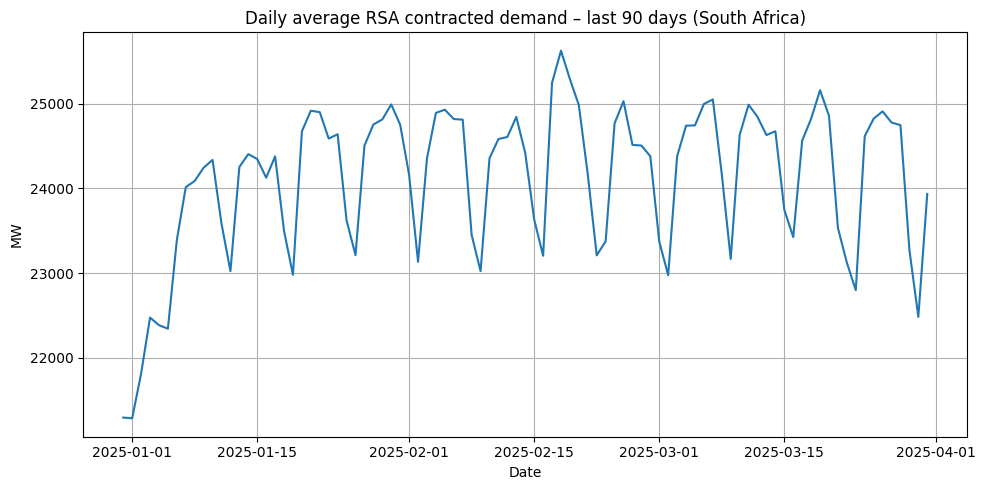

In [4]:
# 3.1 Choose a recent window (last 90 days)
last_date = df.index.max()
start_date = last_date - pd.Timedelta(days=90)

df_90 = df.loc[start_date:last_date]

# 3.2 Aggregate to daily average demand
daily_load = df_90["demand_total"].resample("D").mean()

plt.figure(figsize=(10, 5))
plt.plot(daily_load.index, daily_load.values)
plt.title("Daily average RSA contracted demand – last 90 days (South Africa)")
plt.xlabel("Date")
plt.ylabel("MW")
plt.grid(True)
plt.tight_layout()
plt.show()


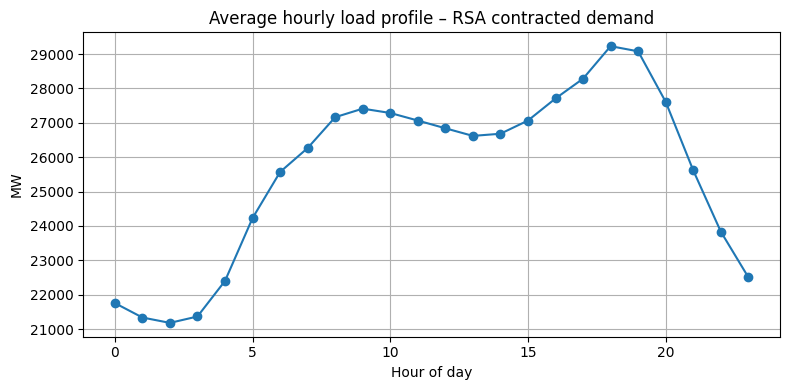

In [5]:
# 3.3 Average load by hour of day over the full sample
hourly_profile = df["demand_total"].groupby(df.index.hour).mean()

plt.figure(figsize=(8, 4))
plt.plot(hourly_profile.index, hourly_profile.values, marker="o")
plt.title("Average hourly load profile – RSA contracted demand")
plt.xlabel("Hour of day")
plt.ylabel("MW")
plt.grid(True)
plt.tight_layout()
plt.show()


This shows the typical daily shape: night valley, morning ramp, evening peak.
- Morning peaks are linked to residential and commercial activity (lighting, heating, appliances).
- Evening peaks reflect household consumption when people return home.

Understanding this shape is essential for:
- （1）Tariff design (time-of-use pricing).
- （2）Demand response programs to flatten peaks.
- （3）Deciding when flexible generation (gas / OCGT) is needed.

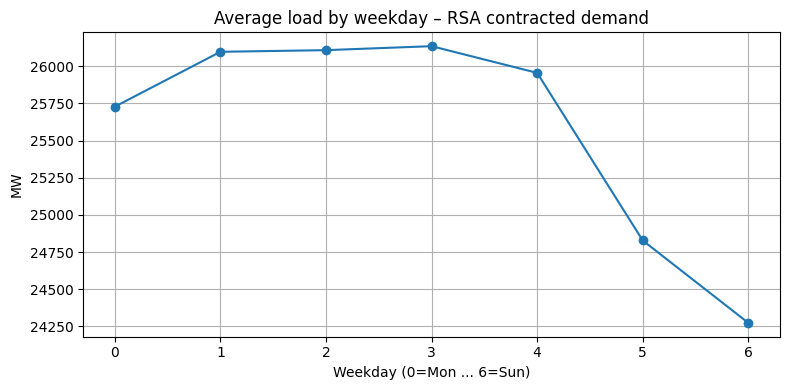

In [6]:
# 3.4 Add weekday information: 0=Monday, ..., 6=Sunday
df["weekday"] = df.index.weekday

weekday_profile = df.groupby("weekday")["demand_total"].mean()

plt.figure(figsize=(8, 4))
plt.plot(weekday_profile.index, weekday_profile.values, marker="o")
plt.title("Average load by weekday – RSA contracted demand")
plt.xlabel("Weekday (0=Mon ... 6=Sun)")
plt.ylabel("MW")
plt.grid(True)
plt.tight_layout()
plt.show()

- This figure highlights differences between weekdays and weekends:
Higher demand on weekdays → more industrial and commercial activity.
Lower demand on weekends → reduced industrial output.

- A strong weekday–weekend gap reflects the weight of energy-intensive industry and mining.
This matters for sectoral policy (e.g. supporting electrification of industry vs households).

## 4. Prepare a daily series for econometric forecasting
- 4.1. we move from hourly data to daily data to focus on medium-term patterns:
（1）Weekly seasonality
（2）Monthly/seasonal trends
Daily aggregation is common in policy and planning studies, where the focus is not individual hours but overall system behaviour.

- 4.2 We simulate a realistic forecasting exercise:
Use historical data up to a certain date (train)
Forecast the next 90 days (test)

In practice, system operators like Eskom need such forecasts to:
Schedule maintenance and coal stockpiles.
Decide how much capacity must be available.
Evaluate the risk of load shedding under demand peaks.

In [7]:
# 4.1 Build a daily dataframe with demand + flexibility / constraints
daily_series = df["demand_unconstrained"].resample("D").mean()  # Daily mean of contracted demand (MW)

daily_df = df[[
    "demand_total", "demand_unconstrained",
    "mlr", "ils",
    "outage_pclf", "outage_uclf", "outage_oclf",
    "pumped_gen_hours",
    "weekday"
]].resample("D").agg({
    "demand_total": "mean",   # Use daily mean for observed demand
    "demand_unconstrained": "mean", # Use daily mean for unconstrained demand proxy
    "mlr": "sum",             # Sum daily load shedding to approximate MWh
    "ils": "sum",             # Sum daily interruptible load activations
    "outage_pclf": "mean",    # Use daily mean for planned outages
    "outage_uclf": "mean",
    "outage_oclf": "mean",
    "pumped_gen_hours": "sum", # Sum daily pumped-storage generation hours
    "weekday": "first"  # Day of week for the aggregated date
}) # Aggregate hourly system data into daily indicators

# Construct weekend dummy  # Calendar-based exogenous regressor
daily_df["is_weekend"] = (daily_df["weekday"] >= 5).astype(int)  # 1=Sat/Sun, 0=Mon–Fri


daily_df = daily_df.loc[daily_series.index]  # Align the multivariate daily panel with the demand series index
daily_df = daily_df.dropna()  # Remove any remaining days with missing values


print("Daily series length:", len(daily_series))  # Print number of daily observations
print("From", daily_series.index.min(), "to", daily_series.index.max())  # Print date range of the daily series

# 4.2 Simple train–test split: last 90 days as test set
test_horizon = 90 # Number of days reserved for testing
train = daily_df.iloc[:-test_horizon]   # Training target series for ARIMA / baseline plots
test  = daily_df.iloc[-test_horizon:]   # Test target series for ARIMA / baseline plots

print("Train period:", train.index.min(), "→", train.index.max())
print("Test period :", test.index.min(),  "→", test.index.max())

#Create aligned train/test splits for the multivariate daily dataframe  # Prepare inputs for SARIMAX and LSTM
train_exog = daily_df.iloc[:-test_horizon]  # Training portion of multivariate daily data
test_exog = daily_df.iloc[-test_horizon:]  # Test portion of multivariate daily data



Daily series length: 1461
From 2021-04-01 00:00:00 to 2025-03-31 00:00:00
Train period: 2021-04-01 00:00:00 → 2024-12-31 00:00:00
Test period : 2025-01-01 00:00:00 → 2025-03-31 00:00:00


## 5. Baseline ARIMA/SARIMA model for daily demand

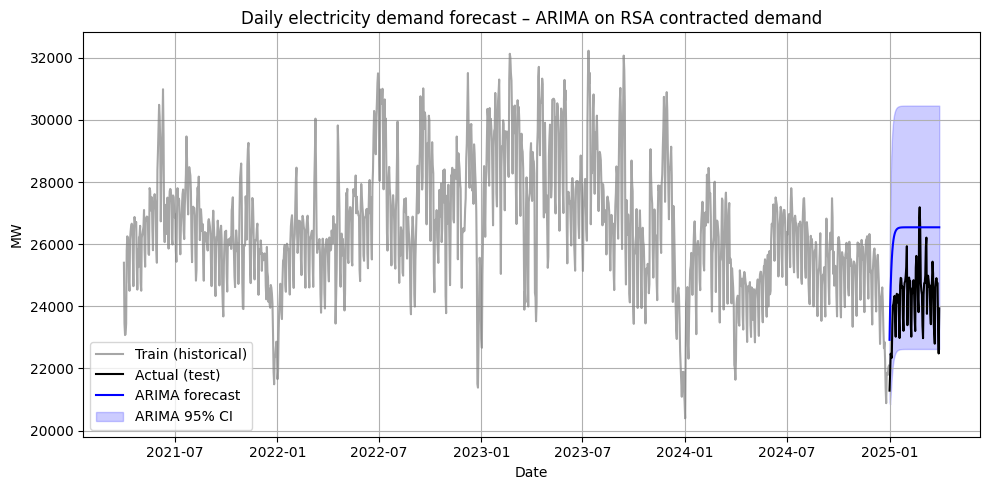

In [8]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Define clean univariate train/test series for ARIMA  # Make sure ARIMA sees only one column (demand)
y_train_arima = daily_series.iloc[:-test_horizon]  # Training series: daily contracted demand before the test window
y_test_arima = daily_series.iloc[-test_horizon:]   # Test series: daily contracted demand over the test window

# ARIMA baseline model (no exogenous regressors)  # Simple benchmark without flexibility or outage information
arima_model = ARIMA(y_train_arima, order=(1, 0, 1))  # Specify a basic ARIMA(p,d,q)=(1,0,1) model
arima_results = arima_model.fit()  # Estimate ARIMA parameters on the training sample

# Produce forecast for the same horizon as SARIMAX  # Forecast the next 'test_horizon' days
arima_forecast_obj = arima_results.get_forecast(steps=test_horizon)
arima_forecast     = arima_forecast_obj.predicted_mean  
arima_ci           = arima_forecast_obj.conf_int()

plt.figure(figsize=(10, 5))  # Create a fresh figure for the ARIMA plot

# Plot historical demand used to estimate the ARIMA model (training sample)
plt.plot(
    y_train_arima.index,      # Datetime index of the training sample
    y_train_arima.values,     # Daily contracted demand (MW) in the training sample
    label="Train (historical)", 
    color="grey", 
    alpha=0.7
)

# Plot actual demand in the test sample (out-of-sample realisation)
plt.plot(
    y_test_arima.index,       # Datetime index of the test sample
    y_test_arima.values,      # Daily contracted demand (MW) in the test sample
    label="Actual (test)", 
    color="black"
)

# Plot ARIMA point forecast for the test horizon
plt.plot(
    arima_forecast.index,
    arima_forecast.values,
    label="ARIMA forecast",
    color="blue"
)


# Plot 95% confidence interval around the ARIMA forecast
plt.fill_between(
    arima_ci.index,           # Datetime index for the confidence intervals
    arima_ci.iloc[:, 0],      # Lower bound of the 95% CI
    arima_ci.iloc[:, 1],      # Upper bound of the 95% CI
    color="blue", 
    alpha=0.2, 
    label="ARIMA 95% CI"
)

plt.title("Daily electricity demand forecast – ARIMA on RSA contracted demand")  # Plot title
plt.xlabel("Date")  # Label x-axis as date
plt.ylabel("MW")  # Label y-axis in MW
plt.legend()  # Show the legend with one entry per line
plt.grid(True)  # Add grid lines
plt.tight_layout()  # Adjust layout to avoid label clipping
plt.show()  # Render the figure



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                     
Dep. Variable:              demand_unconstrained   No. Observations:                 1371
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 7)   Log Likelihood              -10051.377
Date:                           Mon, 26 Jan 2026   AIC                          20126.755
Time:                                   22:25:16   BIC                          20189.293
Sample:                               04-01-2021   HQIC                         20150.171
                                    - 12-31-2024                                         
Covariance Type:                             opg                                         


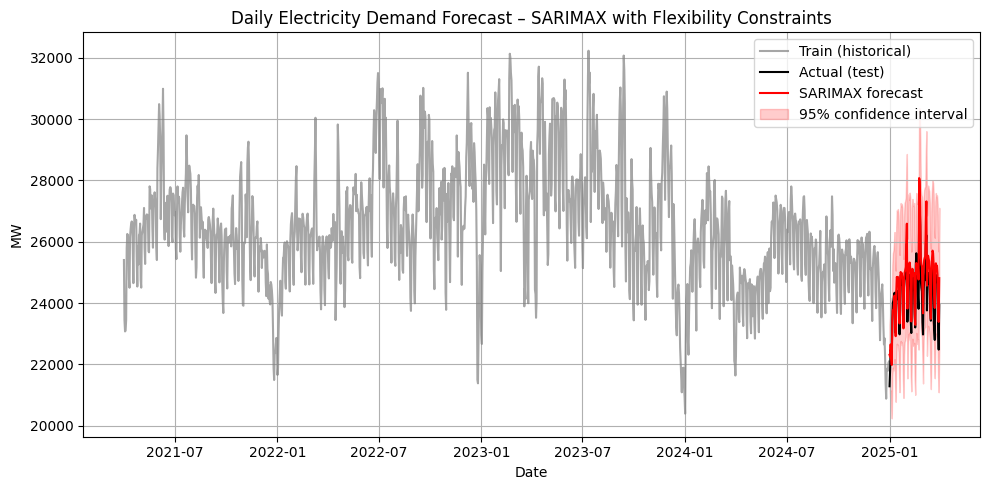

In [9]:
# 5.x SARIMAX with exogenous regressors 

# Exogenous variables for SARIMAX (flexibility + outages + calendar effects)
exog_cols = [
    "mlr", "ils",
    "outage_pclf", "outage_uclf", "outage_oclf",
    "pumped_gen_hours",
    "is_weekend" 
]

# Dependent variable (daily demand) and exogenous matrices
sarimax_train_actual = train["demand_unconstrained"]
sarimax_X_train      = train[exog_cols]

sarimax_actual = test["demand_unconstrained"]
sarimax_X_test = test[exog_cols]

# Define the SARIMAX model
sarimax_model = SARIMAX(
    sarimax_train_actual,
    exog=sarimax_X_train,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_results = sarimax_model.fit(disp=False)

print(sarimax_results.summary().tables[0])

# Forecast for the test horizon (90 days), using future exog = X_test
sarimax_forecast_obj = sarimax_results.get_forecast(
    steps=test_horizon,
    exog=sarimax_X_test
)

sarimax_forecast = sarimax_forecast_obj.predicted_mean
sarimax_ci       = sarimax_forecast_obj.conf_int()

# Plot as before, but using y_test instead of test 
plt.figure(figsize=(10, 5))

plt.plot(
    sarimax_train_actual.index,
    sarimax_train_actual.values,
    label="Train (historical)",
    color="grey",
    alpha=0.7
)

plt.plot(
    sarimax_actual.index,
    sarimax_actual.values,
    label="Actual (test)",
    color="black"
)

plt.plot(
    sarimax_forecast.index,
    sarimax_forecast.values,
    label="SARIMAX forecast",
    color="red"
)

plt.fill_between(
    sarimax_forecast.index,
    sarimax_ci.iloc[:, 0],
    sarimax_ci.iloc[:, 1],
    color="red",
    alpha=0.2,
    label="95% confidence interval"
)

plt.title("Daily Electricity Demand Forecast – SARIMAX with Flexibility Constraints")
plt.xlabel("Date")
plt.ylabel("MW")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




**Model Specification – SARIMAX(1,0,1)×(1,1,1,7)**  
- Non-seasonal: ARIMA(1,0,1)  
- Seasonal: ARIMA(1,1,1) with 7-day seasonality  

**Level Alignment**  
- The red forecast oscillates around the same mean level as the black actual series.
- This means the model correctly captures the average demand level for early 2025.
- Important in South Africa: baseline errors → load shedding risk

**Weekly Oscillation**  
- SARIMA reproduces the weekly up–down pattern, this is exactly the weekly seasonality (7-day cycle) imposed in the model.
- Actual series is noisier (weather, outages, holidays)  
- SARIMA captures structure, not shocks

**Uncertainty Band**  
- Narrow at start, widening over time  
- It becomes wider over time, meaning that forecast uncertainty accumulates.
- Policy implication: requires higher reserve margins

**Model Adequacy**  
Strengths:  
- Actual stays inside 95% CI  
- Weekly pattern captured  

Limitations:  
- No weather/outage/macroeconomic variability  

Conclusion:  
SARIMA is a solid transparent baseline; advanced models can be used later.


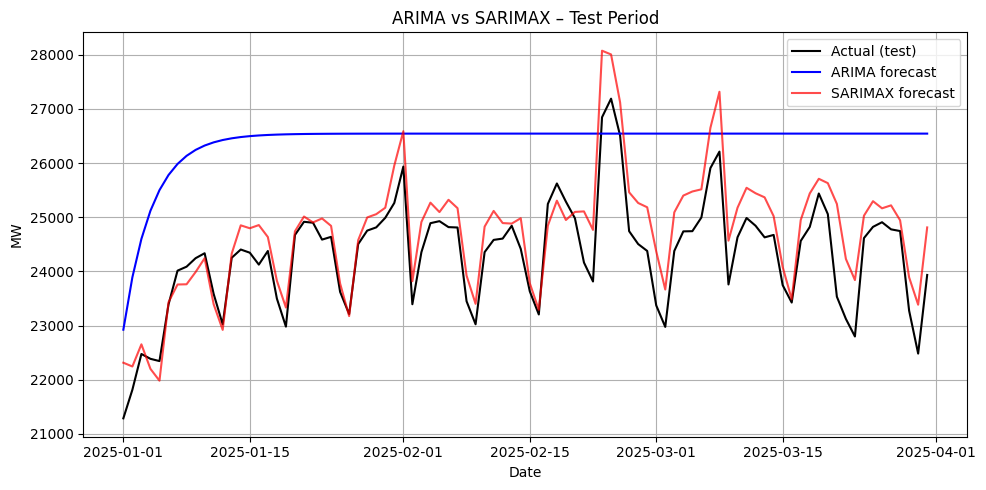

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    sarimax_actual.index,
    sarimax_actual.values,
    label="Actual (test)",
    color="black"
)

plt.plot(
    arima_forecast.index,
    arima_forecast.values,
    label="ARIMA forecast",
    color="blue"
)

plt.plot(
    sarimax_forecast.index,
    sarimax_forecast.values,
    label="SARIMAX forecast",
    color="red",
    alpha=0.7
)

plt.title("ARIMA vs SARIMAX – Test Period")
plt.xlabel("Date")
plt.ylabel("MW")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



- When we zoom into the test period, the non-seasonal ARIMA forecast appears smoother and fails to fully reproduce the weekly pattern.
- The SARIMA specification with a 7-day seasonal component better captures South Africa’s structural weekday–weekend cycle, which is crucial for dispatch and capacity planning in a coal-dominated system.

## 6. LSTM-Based Demand Forecasting

**Objective:**  
Use a Long Short-Term Memory (LSTM) neural network to capture nonlinear patterns, 
weather-dependent behaviour and structural changes in South Africa’s electricity demand.

**Why LSTM?**  
- Traditional SARIMA captures linear and seasonal patterns but struggles with shocks (outages, heatwaves, holidays).  
- LSTM can learn nonlinear dependencies and long-term memory effects 
  (e.g. persistent load patterns, structural shifts in consumption).
- South Africa’s grid, with frequent outages and volatile renewable output, benefits from a more flexible model.

**Workflow:**  
1. Prepare supervised-learning dataset (windowed sequences).  
2. Scale data (LSTM requires normalization).  
3. Build LSTM architecture.  
4. Train–test split.  
5. Forecast next 30–90 days.  
6. Compare with SARIMA and ARIMA baselines.


X shape: (1431, 30, 8)
y shape: (1431,)
Epoch 1/30


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0480 - val_loss: 0.0080
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0135 - val_loss: 0.0056
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0108 - val_loss: 0.0051
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0092 - val_loss: 0.0051
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0077 - val_loss: 0.0052
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0070 - val_loss: 0.0046
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0066 - val_loss: 0.0041
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0065 - val_loss: 0.0036
Epoch 9/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0062 - val_loss: 0.0037
Epoch 10/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0059 - val_loss: 0.0036
Epoch 11/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0056 - val_loss: 0.0035
Epoch 12/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0054 - val_loss: 0.0034


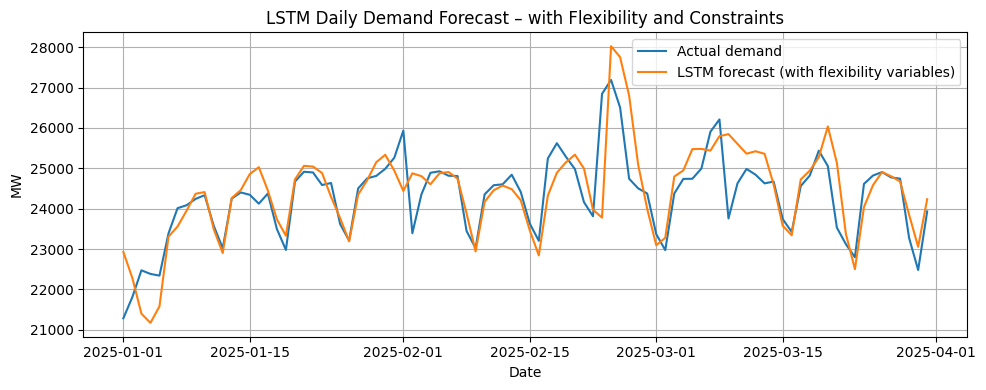

In [11]:
#%pip install tensorflow
from tensorflow import keras
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# 6.1 Use the daily dataframe with demand + flexibility / constraints + calendar
# Keep only rows without NaNs (after our ffill this should be fine)
feature_cols = [
    "demand_unconstrained",
    "mlr", "ils",
    "outage_pclf", "outage_uclf", "outage_oclf",
    "pumped_gen_hours",
    "is_weekend"
]

data = daily_df[feature_cols].dropna()
values = data.values   # shape (T, n_features)

# 6.2 Scale all features jointly
# IMPORTANT: fit scaler on training portion only to prevent data leakage.
# We still transform the full array so that test-set windows can look
# back into the training period (the 30-day lookback window).
test_size = 90
n_train = len(values) - test_size

scaler = MinMaxScaler()
scaler.fit(values[:n_train])           # fit on train only — no look-ahead
values_scaled = scaler.transform(values)  # transform full series

n_features = values_scaled.shape[1]
window_size = 30   # e.g. use last 30 days to predict next day

# 6.3 Create multivariate sequences
def create_sequences_multivariate(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size, :])   # window_size × n_features
        y.append(data[i+window_size, 0])     # target = scaled demand (first column)
    return np.array(X), np.array(y)

X, y = create_sequences_multivariate(values_scaled, window_size)
print("X shape:", X.shape)  # (samples, window_size, n_features)
print("y shape:", y.shape)  # (samples,)

# 6.4 Train–test split (last 90 days as test, consistent with scaler split above)
X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

# 6.5 Define LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(64, activation="tanh", input_shape=(window_size, n_features)))
lstm_model.add(Dense(32, activation="relu"))
lstm_model.add(Dense(1))  # predict next-day demand

lstm_model.compile(optimizer="adam", loss="mse")
history = lstm_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# 6.6 Predict on test set
lstm_pred_scaled = lstm_model.predict(X_test)

# 6.7 Inverse-transform back to MW

def inverse_transform_target(y_scaled, scaler, n_features, target_col_index=0):
    y_scaled = y_scaled.reshape(-1, 1)
    aux = np.zeros((len(y_scaled), n_features))
    aux[:, target_col_index] = y_scaled[:, 0]
    inv = scaler.inverse_transform(aux)
    return inv[:, target_col_index]

lstm_actual   = inverse_transform_target(
    y_test, scaler, n_features, target_col_index=0
)

lstm_forecast = inverse_transform_target(
    lstm_pred_scaled.flatten(), scaler, n_features, target_col_index=0
)

h_lstm = min(len(lstm_forecast), len(sarimax_forecast), test_horizon)
lstm_idx = sarimax_forecast.index[:h_lstm]

lstm_actual = pd.Series(lstm_actual[:h_lstm], index=lstm_idx, name="Actual")
lstm_forecast = pd.Series(lstm_forecast[:h_lstm], index=lstm_idx, name="LSTM")

# 6.8 Plot results
plt.figure(figsize=(10,4))
plt.plot(lstm_actual.index, lstm_actual.values, label="Actual demand")
plt.plot(lstm_forecast.index, lstm_forecast.values, label="LSTM forecast (with flexibility variables)")
plt.title("LSTM Daily Demand Forecast – with Flexibility and Constraints")
plt.ylabel("MW")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




### LSTM Results

**Trend learning**  
- The LSTM captures medium-term and long-term movements in demand.
- It correctly follows structural changes such as the mid-period drop and recovery.

**Smoothing effect**  
- The forecast appears smoother than the actual series.  
- This is expected because a univariate LSTM with a short lookback window 
  cannot fully learn the strong weekday–weekend oscillation.

**Economic interpretation**  
- South African demand shows high volatility driven by weather, outages and 
  industrial cycles.  
- LSTM captures the underlying trend but not the short-term spikes, 
  suggesting the need for additional features (weekday, temperature, outages).

**Conclusion**  
- LSTM improves on ARIMA for nonlinear trend detection.  
- However, SARIMA still outperforms LSTM on weekly seasonality.  
- A hybrid model or LSTM with exogenous variables would likely deliver the best accuracy.


Comparing the three models, 
- ARIMA tends to revert to the mean and misses the weekly cycle, 
- SARIMA captures the structural weekday–weekend pattern quite well
- LSTM improves trend detection but still smooths out short-term volatility. 

This suggests using SARIMA as a transparent benchmark and LSTM as a complementary nonlinear model, especially once we add exogenous variables such as temperature or outage information

alpha (correction strength): 0.3452313012633789


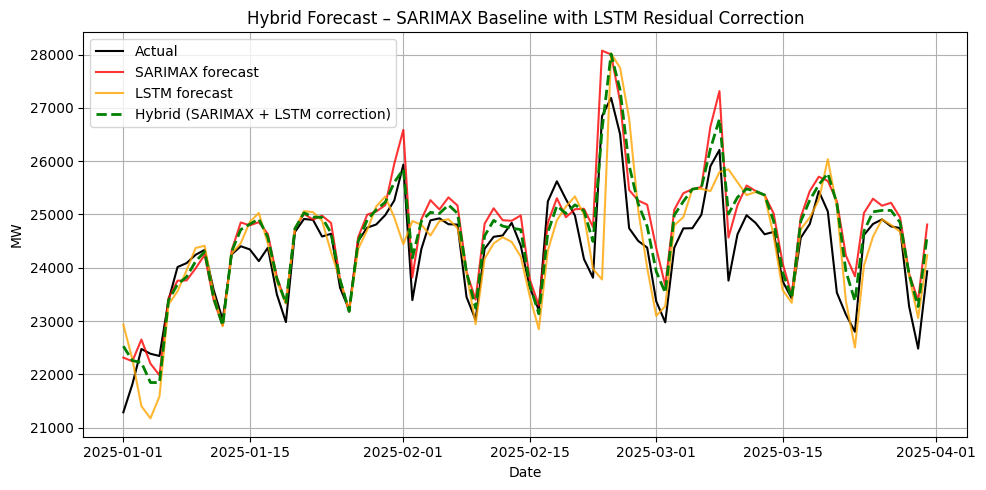

In [12]:
# =======================
# Hybrid (SARIMAX + LSTM residual correction) 
# Requires (article-level variables) to already exist:
#   - daily_series      : pd.Series of actual daily demand (same frequency as forecasts)
#   - test_horizon      : int
#   - arima_forecast    : pd.Series (point forecast over test horizon)
#   - sarimax_forecast  : pd.Series (point forecast over test horizon)
#   - lstm_forecast     : pd.Series or 1D np.ndarray/list (inverse-transformed MW forecast over test horizon)
# Produces:
#   - hybrid_forecast   : pd.Series aligned to the evaluation index
# =======================


# 1) Define the canonical test timeline (use SARIMAX forecast index as reference)
test_idx = sarimax_forecast.index

# 2) Ensure LSTM forecast is a pandas Series aligned to the canonical test timeline
if isinstance(lstm_forecast, pd.Series):
    lstm_forecast_s = lstm_forecast.reindex(test_idx)
else:
    lstm_forecast_s = pd.Series(np.asarray(lstm_forecast).flatten(), index=test_idx, name="LSTM")

# 3) Compute a common horizon h (robust to slight length mismatches / NaNs)
h_arima   = len(arima_forecast.dropna())
h_sarimax = len(sarimax_forecast.dropna())
h_lstm    = len(lstm_forecast_s.dropna())
h = min(h_arima, h_sarimax, h_lstm, test_horizon)

# 4) Common evaluation index (last h dates of the canonical test timeline)
idx = test_idx[-h:]

# 5) Align all series to the same index
actual_h  = daily_series.reindex(idx)
arima_h   = arima_forecast.reindex(idx)   
sarimax_h = sarimax_forecast.reindex(idx)
lstm_h    = lstm_forecast_s.reindex(idx)

# 6) Drop any residual NaNs consistently 
common = pd.concat(
    [actual_h.rename("actual"), sarimax_h.rename("sarimax"), lstm_h.rename("lstm")],
    axis=1
).dropna()

actual_h  = common["actual"]
sarimax_h = common["sarimax"]
lstm_h    = common["lstm"]
idx       = common.index

# 7) Fit alpha: map (LSTM - SARIMAX) onto SARIMAX residuals
delta = (lstm_h - sarimax_h).values
resid = (actual_h - sarimax_h).values

alpha = np.dot(resid, delta) / (np.dot(delta, delta) + 1e-9)
print("alpha (correction strength):", alpha)

# 8) Hybrid forecast 
hybrid_forecast = sarimax_h + alpha * (lstm_h - sarimax_h)
hybrid_forecast.name = "HYBRID"

# 9) Plot 
plt.figure(figsize=(10, 5))
plt.plot(idx, actual_h.values, label="Actual", color="black")
plt.plot(idx, sarimax_h.values, label="SARIMAX forecast", color="red", alpha=0.8)
plt.plot(idx, lstm_h.values, label="LSTM forecast", color="orange", alpha=0.8)
plt.plot(idx, hybrid_forecast.values, label="Hybrid (SARIMAX + LSTM correction)", color="green", linestyle="--", linewidth=2)

plt.title("Hybrid Forecast – SARIMAX Baseline with LSTM Residual Correction")
plt.xlabel("Date")
plt.ylabel("MW")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



## 7. Temporal Fusion Transformer (TFT) for Demand Forecasting

**Objective**

We extend the forecasting toolkit with a Temporal Fusion Transformer (TFT) to generate decision-grade demand trajectories suitable for 
- (i) capacity adequacy checks, 
- (ii) dispatch and marginal pricing analysis, and 
- (iii) scenario stress-testing of the South African power system.

**Why TFT in this energy setting**

Compared to SARIMAX and LSTM, TFT is designed for multi-horizon forecasting with mixed covariates and provides a structured way to incorporate:

- Known future inputs (calendar effects, planned holidays, potentially forecasted weather),
- Observed time-varying inputs (past demand, outages, load shedding proxies),
- Static covariates (system/country-level identifiers if needed).

This matters in electricity systems because peak demand and intra-week seasonality drive:

- reliability risk (reserve margin / load shedding probability),
- dispatch decisions (thermal ramping and peaking units),
- and price formation (scarcity rents during stress hours/days).

**Target variable**

We forecast demand_unconstrained (daily) as the primary target for planning and adequacy assessment, because observed load can be biased downward under rationing (load shedding). This aligns the demand module with the system planning question: “What demand would materialize absent curtailment?”

**Economic interpretation of drivers**

TFT allows us to quantify and communicate which factors move demand:

- Calendar structure (weekday/weekend): proxies industrial/commercial activity cycles.
- Outage indicators: capture supply-side stress that can correlate with rationing patterns and observed consumption.
- Load shedding proxies (MLR): inform the gap between observed and latent demand.
- Pumped storage activity: reflects system balancing needs and stress periods.

In [13]:
# 7.1 Add TFT dependencies
%pip install pytorch-lightning pytorch-forecasting torch
import torch
import lightning.pytorch as pl
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet, GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss


# 7.2 Prepare TFT dataset
# --- TFT dataset preparation ---
tft_df = daily_df[[
    "demand_unconstrained",
    "mlr", "ils",
    "outage_pclf", "outage_uclf", "outage_oclf",
    "pumped_gen_hours",
    "is_weekend"
]].dropna().copy()

# time index required by TFT
tft_df = tft_df.reset_index().rename(columns={"Date Time Hour Beginning": "date"})
tft_df["time_idx"] = (tft_df["date"] - tft_df["date"].min()).dt.days

# single-series group id (extendable if later you add provinces/segments)
tft_df["series_id"] = "ZA_Eskom"

# 7.3 train - test split
max_prediction_length = test_horizon
max_encoder_length = 90  

training_cutoff = tft_df["time_idx"].max() - max_prediction_length

# 7.4 Define TFT dataset
training = TimeSeriesDataSet(
    tft_df[tft_df.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="demand_unconstrained",
    group_ids=["series_id"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    time_varying_known_reals=["time_idx", "is_weekend"],
    time_varying_unknown_reals=[
        "demand_unconstrained",
        "mlr", "ils",
        "outage_pclf", "outage_uclf", "outage_oclf",
        "pumped_gen_hours",
    ],
    target_normalizer=GroupNormalizer(groups=["series_id"]),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation = TimeSeriesDataSet.from_dataset(training, tft_df, predict=True, stop_randomization=True)

train_loader = training.to_dataloader(train=True, batch_size=64, num_workers=0)
val_loader   = validation.to_dataloader(train=False, batch_size=64, num_workers=0)

# 7.5 train TFT model
pl.seed_everything(42)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-3,
    hidden_size=16,
    attention_head_size=4,
    dropout=0.1,
    loss=QuantileLoss(),
)

trainer = pl.Trainer(
    max_epochs=15,
    enable_checkpointing=False,
    logger=False,
    accelerator="cpu",
)

trainer.fit(tft, train_loader, val_loader)

# 7.6 Prodice forecasts and add to the metrics table
tft_pred = tft.predict(val_loader)  # returns a torch tensor or numpy-like
tft_pred = np.array(tft_pred).reshape(-1)

# Align to evaluation index 
h_tft = min(len(tft_pred), len(sarimax_forecast), test_horizon)

tft_forecast = pd.Series(
    tft_pred[:h_tft],
    index=sarimax_forecast.index[:h_tft],
    name="TFT"
)


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pytorch_forecasting/models/base/_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
Seed set to 42
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (mps), used: False
TPU available: False

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    208 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.7 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  6.6 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  1.8 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    676 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 23.9 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 23.9 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 398                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/rich/live.py:256: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightning/pytorch/trainer/connector
s/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightning/pytorch/trainer/connector
s/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=15` reached.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/var/folders/mb/cvcryn1n0qnchrchll5437zc0000gn/T/ipykernel_53613/2161029612.py:81: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-th

In [14]:
forecasts = {}

forecasts["ARIMA"]   = arima_forecast
forecasts["SARIMAX"] = sarimax_forecast
forecasts["LSTM"]    = lstm_forecast
forecasts["HYBRID"]  = hybrid_forecast
forecasts["TFT"]     = tft_forecast

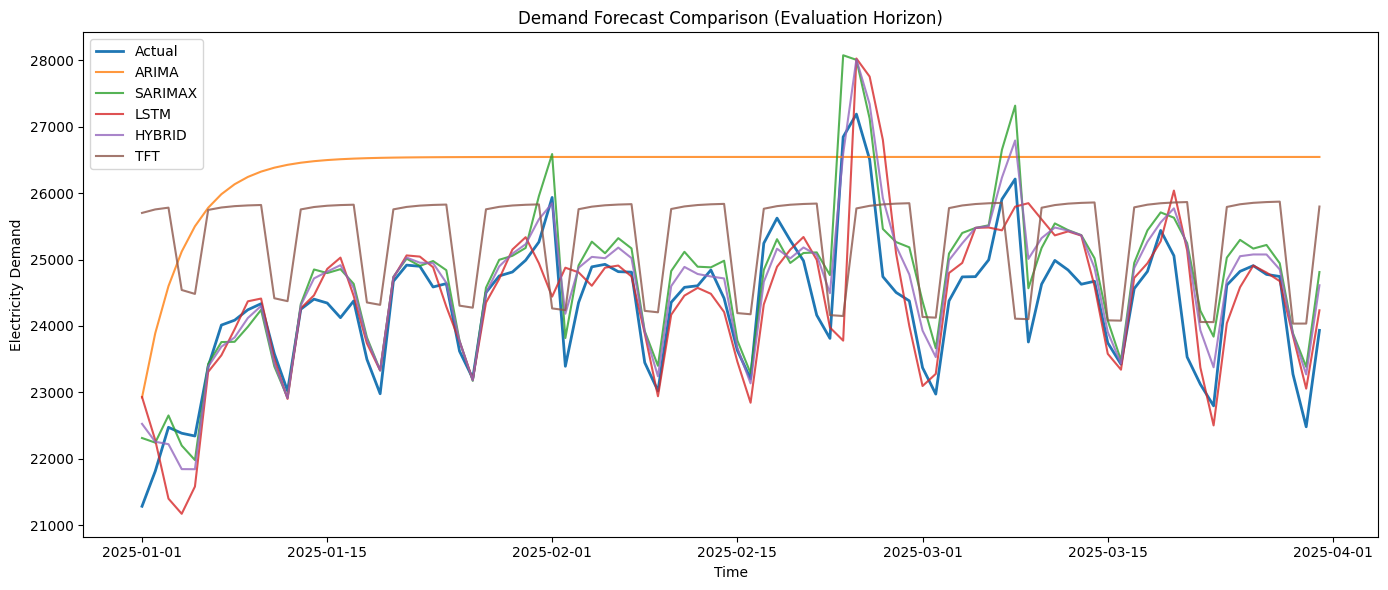

In [15]:

plt.figure(figsize=(14, 6))

plt.plot(actual_h.index, actual_h.values, label="Actual", linewidth=2)

for name, series in forecasts.items():
    plt.plot(series.index, series.values, label=name, alpha=0.8)

plt.title("Demand Forecast Comparison (Evaluation Horizon)")
plt.xlabel("Time")
plt.ylabel("Electricity Demand")
plt.legend()
plt.tight_layout()
plt.show()


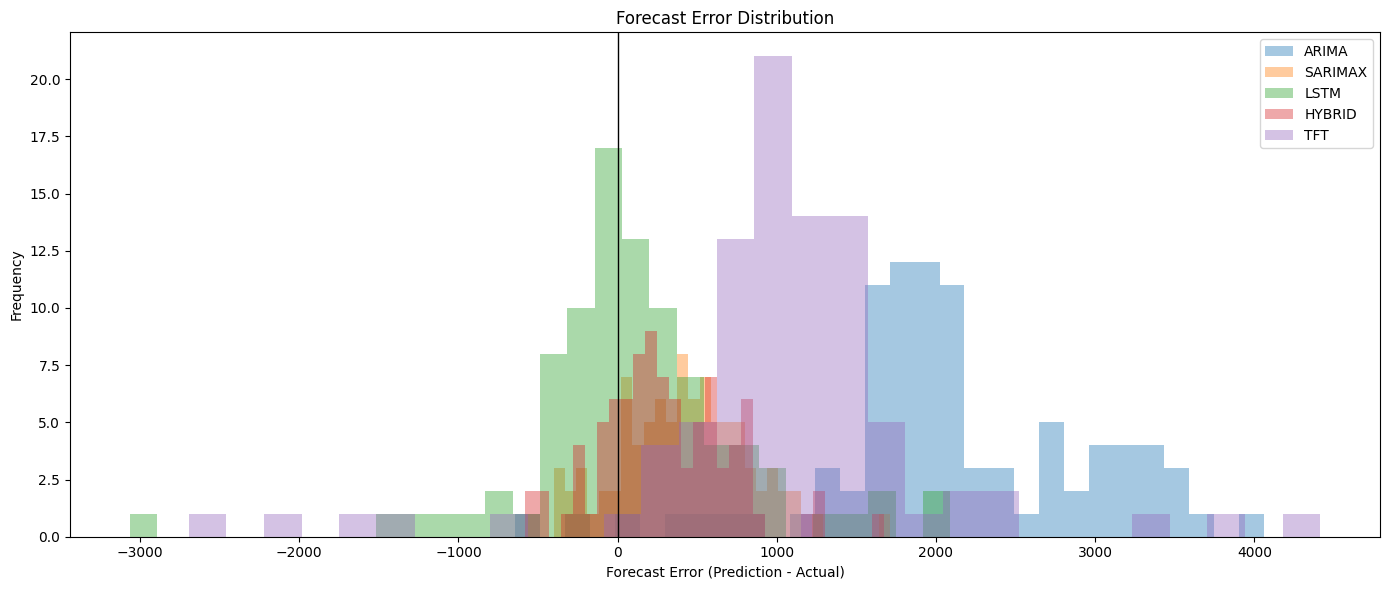

In [16]:
plt.figure(figsize=(14, 6))

for name, series in forecasts.items():
    error = series.values - actual_h.values
    plt.hist(error, bins=30, alpha=0.4, label=name)

plt.axvline(0, color="black", linewidth=1)
plt.title("Forecast Error Distribution")
plt.xlabel("Forecast Error (Prediction - Actual)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
# ============================================================
# Metrics & risk-aware evaluation (mean + tail + pinball loss)
# ============================================================

# -------- inputs (edit here only if needed) --------
y_true_raw = actual_h          # pandas Series preferred; can be array-like
forecasts_raw = forecasts      # dict: {model_name: series_or_array}

# -------- helpers: align to a common index --------
def to_series(x, index=None, name=None):
    """Convert forecast/actual to a pandas Series with a consistent index."""
    if isinstance(x, pd.Series):
        s = x.copy()
        if name is not None:
            s.name = name
        return s
    x = np.asarray(x).reshape(-1)
    if index is None:
        index = pd.RangeIndex(len(x))
    return pd.Series(x, index=index, name=name)

# Build a common index (prefer actual's index if available)
if isinstance(y_true_raw, pd.Series):
    base_index = y_true_raw.index
else:
    # If actual_h is array-like, infer index length from it
    y_true_arr = np.asarray(y_true_raw).reshape(-1)
    base_index = pd.RangeIndex(len(y_true_arr))

y_true = to_series(y_true_raw, index=base_index, name="Actual")

# Convert all forecasts to Series and align
forecast_series = {}
for name, pred in forecasts_raw.items():
    s = to_series(pred, index=base_index, name=name)
    # Align strictly to actual index (drop any mismatched timestamps if any)
    s = s.reindex(base_index)
    forecast_series[name] = s

# -------- metric functions --------
def mae(y, yhat):
    return float(np.mean(np.abs(y - yhat)))

def rmse(y, yhat):
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

def mape(y, yhat, eps=1e-6):
    y = np.asarray(y)
    yhat = np.asarray(yhat)
    denom = np.maximum(np.abs(y), eps)  # protect against near-zero true demand
    return float(np.mean(np.abs((y - yhat) / denom)) * 100)

def bias(y, yhat):
    return float(np.mean(yhat - y))

def p_abs_error(y, yhat, p=95):
    return float(np.percentile(np.abs(y - yhat), p))

def max_abs_error(y, yhat):
    return float(np.max(np.abs(y - yhat)))

def pinball_loss(y, yhat, q=0.5):
    """
    Pinball (quantile) loss for quantile q in (0,1).
    When q=0.95, under-forecasting (y>yhat) is penalized more heavily.
    """
    e = y - yhat
    return float(np.mean(np.maximum(q * e, (q - 1) * e)))

# -------- compute metrics --------
y = y_true.values
rows = []

for name, s_pred in forecast_series.items():
    yhat = s_pred.values

    rows.append({
        "Model": name,

        # Baseline mean-error metrics
        "MAE": mae(y, yhat),
        "RMSE": rmse(y, yhat),
        "Bias": bias(y, yhat),

        # Tail-risk diagnostics (what happens when the model fails)
        "AE_P95": p_abs_error(y, yhat, p=95),
        "AE_P99": p_abs_error(y, yhat, p=99),
        "AE_Max": max_abs_error(y, yhat),

        # Risk-aware asymmetric losses (penalize extreme under/over forecasts)
        "Pinball_q05": pinball_loss(y, yhat, q=0.05),
        "Pinball_q50": pinball_loss(y, yhat, q=0.50),
        "Pinball_q95": pinball_loss(y, yhat, q=0.95),
    })

metrics_df = pd.DataFrame(rows)

# Suggested sort: prioritize risk (under-forecast risk) or tail outcomes
metrics_df_sorted = metrics_df.sort_values(["Pinball_q95", "AE_P95", "MAE"])

metrics_df_sorted


,Model,MAE,RMSE,Bias,AE_P95,AE_P99,AE_Max,Pinball_q05,Pinball_q50,Pinball_q95
1,SARIMAX,473.115656,571.140305,409.438127,1035.324727,1282.428873,1713.679817,420.804985,236.557828,52.310671
3,HYBRID,397.757640,508.822100,305.488975,872.968720,1297.904172,1676.272539,336.348859,198.878820,61.408781
0,ARIMA,2111.945173,2259.917362,2090.905146,3476.237253,3780.912062,4061.715035,1996.879902,1055.972587,115.065271
4,TFT,1239.046296,1417.096178,1047.022995,2346.917921,3992.701896,4415.302047,1090.683496,619.523148,148.362800
2,LSTM,469.803297,707.807293,108.338107,1554.903689,2197.059190,3066.213535,283.653797,234.901649,186.149501
